# **Development of a Web and Phone Camera-based Deep Learning System for Detection and Identification of Banana Plant Leaf Diseases**

---



**Importing Libraries**

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os #OS library to check if folders exists
import numpy as np

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import colors

**Mounting Google Drive**

In [ ]:
from google.colab import drive #Importing Google Drive module
drive.mount("/content/drive") #Mounting Google Drive

#Defining directory paths
train = "/content/drive/MyDrive/Banana Disease Detection/dataset/training set" #Contains augmented images to be used for training
test = "/content/drive/MyDrive/Banana Disease Detection/dataset/test set" #Contains images to be used for testing

#Defining directory paths - AUGMENTED
training_set = "/content/drive/MyDrive/Banana Disease Detection/augmented dataset/training set" #Contains augmented images to be used for training

#Checking if folders directory are found

#Original Dataset
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset/training set"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset/test set"))

#Augmented Dataset for Training
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/augmented dataset"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/augmented dataset/training set"))

Mounted at /content/drive
['test set', 'training set']
['black sigatoka', 'yellow sigatoka', 'panama disease', 'healthy leaves']
['black sigatoka', 'healthy leaves', 'panama disease', 'yellow sigatoka']
['training set']
['black sigatoka', 'yellow sigatoka', 'healthy leaves', 'panama disease']


# **Data Preprocessing**

**Training Image Preprocessing - Original**

In [ ]:
train_ds, validation_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(512, 512),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="both",
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 1496 files belonging to 4 classes.
Using 1197 files for training.
Using 299 files for validation.


In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

**Preprocessing - ResNet50**

In [ ]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

validation_ds = validation_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

**Dataset Visualization - Original**

In [ ]:
for x,y in train_ds:
  print(x)
  print(y)
  break

tf.Tensor(
[[[[ 33.810997    23.971       21.07      ]
   [ 38.310997    28.846       26.445     ]
   [ 48.185997    35.346       25.445     ]
   ...
   [ 15.560997     5.3460007  -29.43      ]
   [ 15.185997     6.0960007  -27.18      ]
   [ 20.435997     6.3460007  -24.555     ]]

  [[ 36.435997    26.596       23.695     ]
   [ 39.435997    29.221       25.32      ]
   [ 49.685997    36.846       26.945     ]
   ...
   [ 17.060997     6.4710007  -29.43      ]
   [ 15.560997     4.9710007  -27.93      ]
   [ 21.560997     5.2210007  -26.43      ]]

  [[ 36.435997    26.346       22.695     ]
   [ 40.810997    27.846       23.445     ]
   [ 49.060997    34.721       25.32      ]
   ...
   [ 23.310997     9.471001   -24.93      ]
   [ 23.810997    11.471001   -21.93      ]
   [ 23.310997     6.3460007  -26.305     ]]

  ...

  [[-33.564003    -6.9039993    4.1949997 ]
   [-33.564003    -5.1539993    2.9449997 ]
   [-29.689003    -0.5289993    9.07      ]
   ...
   [ 19.560997     6.721

In [ ]:
for x, y in train_ds:
  print(x.shape)
  print(y.shape)
  break

(32, 512, 512, 3)
(32, 4)


# **Model Training - ResNet50**

**Building Model - ResNet50**

In [ ]:
# Load the ResNet50 model with pre-trained ImageNet weights
resnet_base_model = ResNet50(
    weights='imagenet',
    include_top=False, # Do not include the ImageNet classifier at the top
    input_shape=(512, 512, 3) # Specify the input shape
)

# Freeze the layers of the base model
resnet_base_model.trainable = False

# Add custom classification layers on top of ResNet50
x_resnet = resnet_base_model.output
x_resnet = layers.GlobalAveragePooling2D()(x_resnet)
x_resnet = layers.Dense(256, activation='relu')(x_resnet)
x_resnet = layers.Dropout(0.4)(x_resnet)

# Output layer with 4 classes (assuming the same as your current problem)
output_resnet = layers.Dense(4, activation='softmax')(x_resnet)

# Create the new model
resnet_model = tf.keras.models.Model(inputs=resnet_base_model.input, outputs=output_resnet)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Training Model - ResNet50**

In [ ]:
# Compile the model (using the same optimizer and loss as before)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy', # Changed from sparse_categorical_crossentropy
    metrics=['accuracy']
)

resnet_early_stopping = EarlyStopping(
    monitor='val_loss',     # Metric to monitor
    patience=5,            # Number of epochs to wait for improvement
    restore_best_weights=False # Revert to the best weights after stopping
)

# Train the ResNet model
resnet_history = resnet_model.fit(
    train_ds,
    epochs = 100,
    validation_data = validation_ds,
    callbacks=[resnet_early_stopping]
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 264s 6s/step - accuracy: 0.5982 - loss: 1.0249 - val_accuracy: 0.8930 - val_loss: 0.4173
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 787ms/step - accuracy: 0.8396 - loss: 0.4635 - val_accuracy: 0.9231 - val_loss: 0.2985
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 784ms/step - accuracy: 0.8889 - loss: 0.3317 - val_accuracy: 0.9331 - val_loss: 0.2260
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 781ms/step - accuracy: 0.9081 - loss: 0.2691 - val_accuracy: 0.9498 - val_loss: 0.1842
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 790ms/step - accuracy: 0.9223 - loss: 0.2420 - val_accuracy: 0.9532 - val_loss: 0.1650
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 786ms/step - accuracy: 0.9390 - loss: 0.1961 - val_accuracy: 0.9699 - val_loss: 0.1366
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 787ms/step - accuracy: 0.9465 - loss: 0.1741 - val_accuracy: 0.9599 - val_loss: 0.1226
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 807ms/step - accuracy: 0.9465 - loss: 0.1606 - va

**Saving Trained Model - ResNet50**

In [ ]:
import json

# Save the trained ResNet model
resnet_model.save("/content/drive/MyDrive/Banana Disease Detection/model/ResNet50/trained_ResNet50.keras")
resnet_model.save("/content/drive/MyDrive/Banana Disease Detection/model/ResNet50/trained_ResNet50.h5")

# Save the ResNet training history
with open('/content/drive/MyDrive/Banana Disease Detection/model/ResNet50/ResNet50_history.json', 'w') as f:
    json.dump(resnet_history.history, f)

**Test Image Training - Original**

In [17]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(512, 512),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 162 files belonging to 4 classes.


**Prepocessing - Test set**

In [18]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

**Accuracy Visualization - ResNet50**

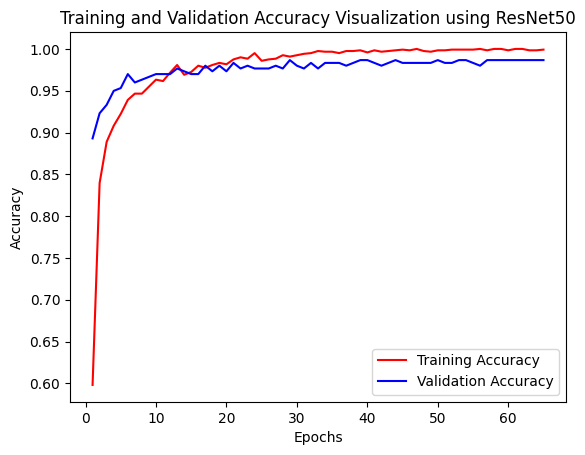

In [ ]:
epochs = range(1, len(resnet_history.history["accuracy"]) + 1)
plt.plot(epochs, resnet_history.history["accuracy"], color = "red", label = "Training Accuracy")
plt.plot(epochs, resnet_history.history["val_accuracy"], color = "blue", label = "Validation Accuracy")
plt.title("Training and Validation Accuracy Visualization using ResNet50")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Trained Model Evaluation - ResNet50**

In [ ]:

#Model Evaluation on Training Set
training_loss, training_accuracy = resnet_model.evaluate(train_ds)

#Model Evaluation on Validation Set
validation_loss, validation_accuracy = resnet_model.evaluate(validation_ds)

print("Model Used: ResNet50")

#Displaying Number of Epochs done
print(f"Number of Epochs completed: {len(resnet_history.history['accuracy'])}", "out of 100")

#Displaying Training Data Evaluation
print(f"Training Accuracy: {training_accuracy*100:.2f}%")
print(f"Training Loss: {training_loss*100:.2f}%")

#Displaying Validation Data Evaluation
print(f"Validation Accuracy: {validation_accuracy*100:.2f}%")
print(f"Validation Loss: {validation_loss*100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 25s 643ms/step - accuracy: 1.0000 - loss: 0.0039
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 476ms/step - accuracy: 0.9866 - loss: 0.0496
Model Used: ResNet50
Number of Epochs completed: 65 out of 100
Training Accuracy: 100.00%
Training Loss: 0.39%
Validation Accuracy: 98.66%
Validation Loss: 4.96%


# **Metrics - ResNet50**

**In-case the runtime stop**

In [62]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os #OS library to check if folders exists
import numpy as np

from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import colors

**Mounting Google Drive**

In [63]:
from google.colab import drive #Importing Google Drive module
drive.mount("/content/drive") #Mounting Google Drive

#Defining directory paths
train = "/content/drive/MyDrive/Banana Disease Detection/dataset/training set" #Contains augmented images to be used for training
test = "/content/drive/MyDrive/Banana Disease Detection/dataset/test set" #Contains images to be used for testing

#Defining directory paths - AUGMENTED
training_set = "/content/drive/MyDrive/Banana Disease Detection/augmented dataset/training set" #Contains augmented images to be used for training

#Checking if folders directory are found

#Original Dataset
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset/training set"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/dataset/test set"))

#Augmented Dataset for Training
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/augmented dataset"))
print(os.listdir("/content/drive/MyDrive/Banana Disease Detection/augmented dataset/training set"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test set', 'training set']
['black sigatoka', 'yellow sigatoka', 'panama disease', 'healthy leaves']
['black sigatoka', 'healthy leaves', 'panama disease', 'yellow sigatoka']
['training set']
['black sigatoka', 'yellow sigatoka', 'healthy leaves', 'panama disease']


In [64]:
# Loading trained model
resnet_model = tf.keras.models.load_model("/content/drive/MyDrive/Banana Disease Detection/model/ResNet50/v4/0.0001/trained_ResNet50.keras")

# The image_dataset_from_directory function infers class names from subdirectories
# and sorts them alphabetically if class_names is not explicitly provided.
# We can replicate this behavior to get the correct class order.
class_name = sorted(os.listdir(train))
class_name

['black sigatoka', 'healthy leaves', 'panama disease', 'yellow sigatoka']

In [65]:
y_predict = resnet_model.predict(test_ds)

# Getting Confidence Score
confidences = np.max(y_predict, axis=1)

y_predict, y_predict.shape

6/6 ━━━━━━━━━━━━━━━━━━━━ 196s 30s/step


(array([[9.99921799e-01, 9.67114833e-09, 7.03237602e-05, 7.87345016e-06],
        [9.99811232e-01, 4.57389033e-05, 9.31661561e-05, 4.98160589e-05],
        [9.99968648e-01, 5.10145867e-07, 2.82569381e-05, 2.67446489e-06],
        [9.99918699e-01, 9.02568686e-10, 7.22840123e-05, 9.09140363e-06],
        [7.46648610e-01, 1.90670833e-01, 6.26425147e-02, 3.79737212e-05],
        [9.99699354e-01, 6.01812289e-08, 1.48480191e-04, 1.52118184e-04],
        [9.97380912e-01, 3.12306314e-09, 3.33407706e-06, 2.61574960e-03],
        [9.97303486e-01, 2.05436027e-06, 2.80999357e-05, 2.66642147e-03],
        [9.99334991e-01, 9.38400149e-08, 6.65025709e-06, 6.58233301e-04],
        [9.99809682e-01, 3.53779654e-08, 1.57464262e-06, 1.88828140e-04],
        [9.98377323e-01, 1.16854324e-04, 1.30838191e-03, 1.97412868e-04],
        [9.99891400e-01, 8.36268943e-10, 6.55193026e-06, 1.02088212e-04],
        [9.99723852e-01, 9.71926895e-09, 2.26496981e-04, 4.96240864e-05],
        [9.99057591e-01, 2.50401344e-0

In [66]:
predicted_categories = tf.argmax(y_predict, axis=1)
predicted_categories

<tf.Tensor: shape=(162,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 3, 3, 0, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3])>

**Confidence Scores - ResNet50**

In [67]:
for i in range(len(predicted_categories)):
  formatted_name = class_name[predicted_categories[i]].title()
  print(
      "Prediction:", formatted_name,
      f"\nConfidence Score: {confidences[i]*100:.2f}%"
  )

Prediction: Black Sigatoka 
Confidence Score: 99.99%
Prediction: Black Sigatoka 
Confidence Score: 99.98%
Prediction: Black Sigatoka 
Confidence Score: 100.00%
Prediction: Black Sigatoka 
Confidence Score: 99.99%
Prediction: Black Sigatoka 
Confidence Score: 74.66%
Prediction: Black Sigatoka 
Confidence Score: 99.97%
Prediction: Black Sigatoka 
Confidence Score: 99.74%
Prediction: Black Sigatoka 
Confidence Score: 99.73%
Prediction: Black Sigatoka 
Confidence Score: 99.93%
Prediction: Black Sigatoka 
Confidence Score: 99.98%
Prediction: Black Sigatoka 
Confidence Score: 99.84%
Prediction: Black Sigatoka 
Confidence Score: 99.99%
Prediction: Black Sigatoka 
Confidence Score: 99.97%
Prediction: Black Sigatoka 
Confidence Score: 99.91%
Prediction: Black Sigatoka 
Confidence Score: 99.91%
Prediction: Black Sigatoka 
Confidence Score: 99.99%
Prediction: Black Sigatoka 
Confidence Score: 100.00%
Prediction: Black Sigatoka 
Confidence Score: 100.00%
Prediction: Black Sigatoka 
Confidence Scor

**Confidence Scores Visualization**

In [68]:
class_name = sorted(os.listdir(train))

class_name = ['Black Sigatoka', 'Healthy Leaves', 'Panama Disease', 'Yellow Sigatoka']# Use the first letter of each class name as the key
class_totals = {name[0].upper(): [] for name in class_name}

for i in range(len(predicted_categories)):
    # Get the letter B, H, Y, or P
    letter = class_name[predicted_categories[i]][0].upper()
    score = confidences[i]
    class_totals[letter].append(score)

avg_confidences = {}
for name, scores in class_totals.items():
    avg_confidences[name] = np.mean(scores) if len(scores) > 0 else 0.0

print("--- Average Confidence per Class ---")
for name, avg in avg_confidences.items():
    print(f"{name}: {avg*100:.2f}%")

--- Average Confidence per Class ---
B: 95.50%
H: 99.86%
P: 97.68%
Y: 97.71%


In [69]:
true_categories = tf.concat([y for x,y in test_ds], axis = 0)
true_categories

<tf.Tensor: shape=(162, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],


In [70]:
Y_true = true_categories
Y_true

<tf.Tensor: shape=(162, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],


**Precision - Recall - F1-Score**

In [71]:
print(classification_report(tf.argmax(Y_true, axis=1), predicted_categories, target_names=class_name))

                 precision    recall  f1-score   support

 Black Sigatoka       0.93      1.00      0.97        42
 Healthy Leaves       1.00      1.00      1.00        41
 Panama Disease       1.00      0.95      0.97        41
Yellow Sigatoka       1.00      0.97      0.99        38

       accuracy                           0.98       162
      macro avg       0.98      0.98      0.98       162
   weighted avg       0.98      0.98      0.98       162



# **Generating Confusion Matrix**

In [72]:
cm = confusion_matrix(tf.argmax(Y_true, axis=1), predicted_categories)
cm

array([[42,  0,  0,  0],
       [ 0, 41,  0,  0],
       [ 2,  0, 39,  0],
       [ 1,  0,  0, 37]])

**Confusion Matrix Visualization**

Text(95.72222222222221, 0.5, 'Actual Class')

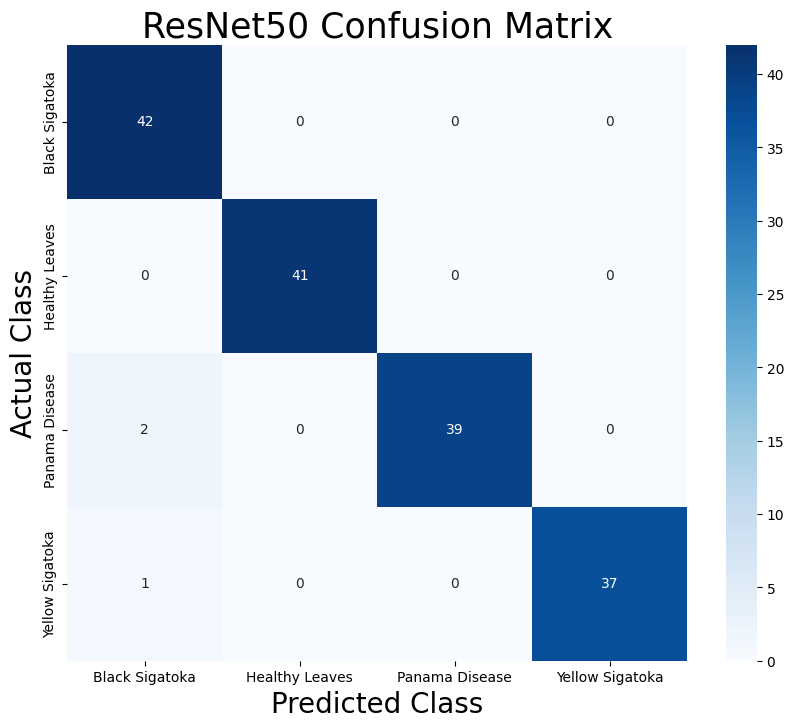

In [73]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_name, yticklabels=class_name)
plt.title('ResNet50 Confusion Matrix', fontsize = 25)
plt.xlabel('Predicted Class', fontsize = 20)
plt.ylabel('Actual Class', fontsize = 20)

In [74]:
for class_name in os.listdir(train):
    class_path = os.path.join(train, class_name)
    if os.path.isdir(class_path):
        print(class_name, len(os.listdir(class_path)))

black sigatoka 379
yellow sigatoka 365
panama disease 377
healthy leaves 375


**Top-1 Accuracy and Top-5 Accuracy**

In [75]:
# Using the functional metrics
m1 = tf.keras.metrics.SparseCategoricalAccuracy()
m5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

# Update states with your model output (y_predict) and labels (Y_true)
m1.update_state(tf.argmax(Y_true, axis=1), y_predict)
m5.update_state(tf.argmax(Y_true, axis=1), y_predict)

print(f"Top-1 Accuracy: {m1.result().numpy():.4f}")
print(f"Top-5 Accuracy: {m5.result().numpy():.4f}")

Top-1 Accuracy: 0.9815
Top-5 Accuracy: 1.0000
